# MSADS 599 - Modeling Part 1 - Classification - Logistic Regression

## Setup

Import Packages

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from huggingface_hub import hf_hub_download, login
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder, StandardScaler

# This shows all columns when analyzing the data
pd.set_option('display.max_columns', None)

Connect to HuggingFace and Import Data

In [2]:
# Connection to HuggingFace via API token
login(token="HF_TOKEN")

In [3]:
# Import training data
train_path = hf_hub_download(
    repo_id = "ADS599-Capstone/modeling_data",
    filename = "part1_train/part1_train-00000-of-00001.parquet",
    repo_type = "dataset"
)

train_df = pd.read_parquet(train_path)
print(train_df.shape)

(67085, 73)


In [4]:
# Import testing data
test_path = hf_hub_download(
    repo_id = "ADS599-Capstone/modeling_data",
    filename = "part1_test/part1_test-00000-of-00001.parquet",
    repo_type = "dataset"
)

test_df = pd.read_parquet(test_path)
print(test_df.shape)

(16882, 73)


## Modeling

Clean and Set the Target Variable

In [13]:
icu_labels = {'ED_DIRECT_ICU', 'ED_WARD_ICU'}

train_df['target'] = train_df['cohort_label'].apply(lambda x: 1 if x in icu_labels else 0)
test_df['target'] = test_df['cohort_label'].apply(lambda x: 1 if x in icu_labels else 0)

# Fit ONLY on train, transform both
le = LabelEncoder()
train_df['target'] = le.fit_transform(train_df['target'])
test_df['target'] = le.transform(test_df['target'])  # ← transform only, not fit_transform

class_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(class_mapping)

{np.int64(0): np.int64(0), np.int64(1): np.int64(1)}


In [14]:
train_df.head()

,gender,anchor_age,height,weight,height_missing,weight_missing,current_temperature,current_heartrate,current_resprate,current_o2sat,current_sbp,current_dbp,current_pain,current_pulse_pressure,current_map,pain_missing,acuity,arrival_transport_AMBULANCE,arrival_transport_HELICOPTER,arrival_transport_OTHER,arrival_transport_UNKNOWN,arrival_transport_WALK IN,admission_type_AMBULATORY OBSERVATION,admission_type_DIRECT EMER.,admission_type_DIRECT OBSERVATION,admission_type_ELECTIVE,admission_type_EU OBSERVATION,admission_type_EW EMER.,admission_type_OBSERVATION ADMIT,admission_type_SURGICAL SAME DAY ADMISSION,admission_type_URGENT,admission_missing,recon_ace_inhibitor,recon_analgesic___nsaid,recon_analgesic___opioid_nsaid,recon_antiarrhythmic,recon_antibiotic,recon_anticoagulant,recon_anticonvulsant,recon_antiemetic,recon_antiplatelet,recon_antipsychotic,recon_benzodiazepine___sedative_anxiolytic,recon_beta_blocker,recon_bronchodilator,recon_calcium_channel_blocker,recon_corticosteroid,recon_diuretic,recon_gi___acid_suppression,recon_insulin_glucose,recon_nitrate,cc_abdominal_pain,cc_altered_mental_status,cc_back_pain,cc_bleeding,cc_chest_pain,cc_dyspnea,cc_fall,cc_fever,cc_headache,cc_leg_complaint,cc_nausea_vomiting,cc_other,cc_pain_other,cc_palpitations,cc_psychiatric_overdose,cc_seizure,cc_stroke_like,cc_syncope,cc_trauma,cc_urinary,cc_weakness_fatigue,cohort_label,target
0,1,0.655388,0.242473,-0.011728,0,1,0.648962,0.582107,0.067360,-2.503481,1.149266,-1.495269,-0.998129,2.462464,-0.408627,0,-0.838847,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,ED_WARD_DISCHARGE,0
1,1,-0.792707,-0.708200,-0.011728,1,1,0.745960,-0.030630,0.067360,0.829348,-0.481359,-0.095955,-0.998129,-0.481267,-0.299804,0,0.603745,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,ED_DISCHARGE_STABLE,0
2,0,-0.892576,0.271725,-0.011728,0,1,-0.321011,1.139140,0.067360,0.829348,2.471394,2.369504,1.400515,1.041352,2.762875,0,-0.838847,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,1,0,0,1,0,0,1,0,0,1,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,ED_WARD_DISCHARGE,0
3,1,-0.592970,0.257099,-0.002756,0,0,-0.321011,0.136480,0.067360,0.353230,0.267847,1.569896,1.133999,-0.887298,1.155294,0,0.603745,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,1,0,1,1,0,0,1,1,0,1,1,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,ED_WARD_DISCHARGE,0
4,1,0.056176,0.069451,-0.011728,0,1,0.260973,0.192183,-0.280298,-0.122889,-0.305075,0.037313,1.133999,-0.379759,-0.125818,0,-0.838847,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,1,1,0,1,0,1,1,1,0,0,1,1,0,0,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,ED_WARD_DISCHARGE,0


In [15]:
# Split the target variable from the test and train datasets

# Training Set
X_train = train_df.drop(columns=['cohort_label', 'target'])
y_train = train_df['target']

# Testing Set
X_test = test_df.drop(columns=['cohort_label', 'target'])
y_test = test_df['target']

# Sanity Check
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")

X_train: (67085, 72), y_train: (67085,)
X_test: (16882, 72), y_test: (16882,)


Train the Model

In [16]:
log_model = LogisticRegression(
    solver='saga',
    max_iter=1000,
    class_weight='balanced',
    random_state=35,
    C=1.0,
    penalty='elasticnet',
    l1_ratio=0
)

log_model.fit(X_train, y_train)

# Best Logistic Regression Hyperparameters
# ElasticNet with saga solver

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


LogisticRegression(class_weight='balanced', l1_ratio=0, max_iter=1000,
                   penalty='elasticnet', random_state=35, solver='saga')

Evaluate the Model

              precision    recall  f1-score   support

   Discharge       0.93      0.77      0.84     13232
         ICU       0.48      0.78      0.60      3650

    accuracy                           0.77     16882
   macro avg       0.70      0.77      0.72     16882
weighted avg       0.83      0.77      0.79     16882



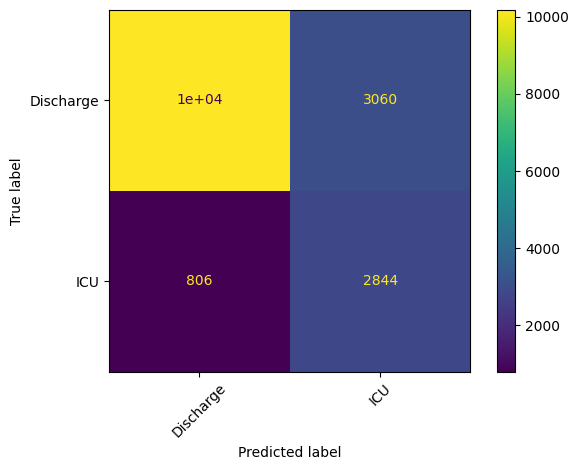

In [18]:
target_names = ['Discharge', 'ICU']  # index 0=Discharge, 1=ICU

y_pred = log_model.predict(X_test)

print(classification_report(y_test, y_pred, target_names=target_names))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(xticks_rotation=45)
plt.tight_layout()
plt.show()